In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, TimeDistributed, Bidirectional
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.metrics import categorical_accuracy
from tensorflow.keras import backend as K
from core.data import load_from_kaggle


c:\Users\yamen\Desktop\Weiterbildung\visual Studio Code\mein-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_link = "alfrandom/protein-secondary-structure" # replace with your dataset link from Kaggle 
destination = "../data/raw"
dataset_name = dataset_link.split("/")[-1]

files = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
    )

Destination directory '../data/raw\protein-secondary-structure' already exists with files. Skipping download (replace=False).


In [3]:
files

['2018-06-06-pdb-intersect-pisces.csv', '2018-06-06-ss.cleaned.csv']

In [4]:
df = pd.read_csv('../data/raw/protein-secondary-structure/2018-06-06-ss.cleaned.csv')
df.head()

,pdb_id,chain_code,seq,sst8,sst3,len,has_nonstd_aa
0,1A30,C,EDL,CBC,CEC,3,False
1,1B05,B,KCK,CBC,CEC,3,False
2,1B0H,B,KAK,CBC,CEC,3,False
3,1B1H,B,KFK,CBC,CEC,3,False
4,1B2H,B,KAK,CBC,CEC,3,False


In [5]:
display(
    "Shape",
    df.shape,
    "Description",
    df.describe().round(2).T,
    "Duplicates",
    df.duplicated().sum(),
)


pd.DataFrame(
    {
        "Data Types": df.dtypes,
        "Missing Values": df.isnull().sum(),
        "Unique Values": df.nunique(),
        "Sample Values": [df[col].sample(3).tolist() for col in df.columns]
    })


'Shape'

(393732, 7)

'Description'

,count,mean,std,min,25%,50%,75%,max
len,393732.0,260.21,196.86,3.0,131.0,223.0,336.0,5037.0


'Duplicates'

np.int64(0)

,Data Types,Missing Values,Unique Values,Sample Values
pdb_id,object,0,139496,"[5M2P, 1SZK, 1PVH]"
chain_code,object,0,62,"[u, D, B]"
seq,object,0,95915,[GPLGSMSIQKVHAREILDSRGNPTIEVEITTGKGMFRSCVPSGAS...
sst8,object,0,329636,[CCCCCCCCCCCSHHHHHHTTTTCCTTCSSCHHHHHHTTEEECSST...
sst3,object,0,289917,[CCCEEEEEEEECCCHHHHHCCHHHCCCCCCCCEEEEEEEEECCCC...
len,int64,0,1366,"[126, 219, 117]"
has_nonstd_aa,bool,0,2,"[False, False, False]"


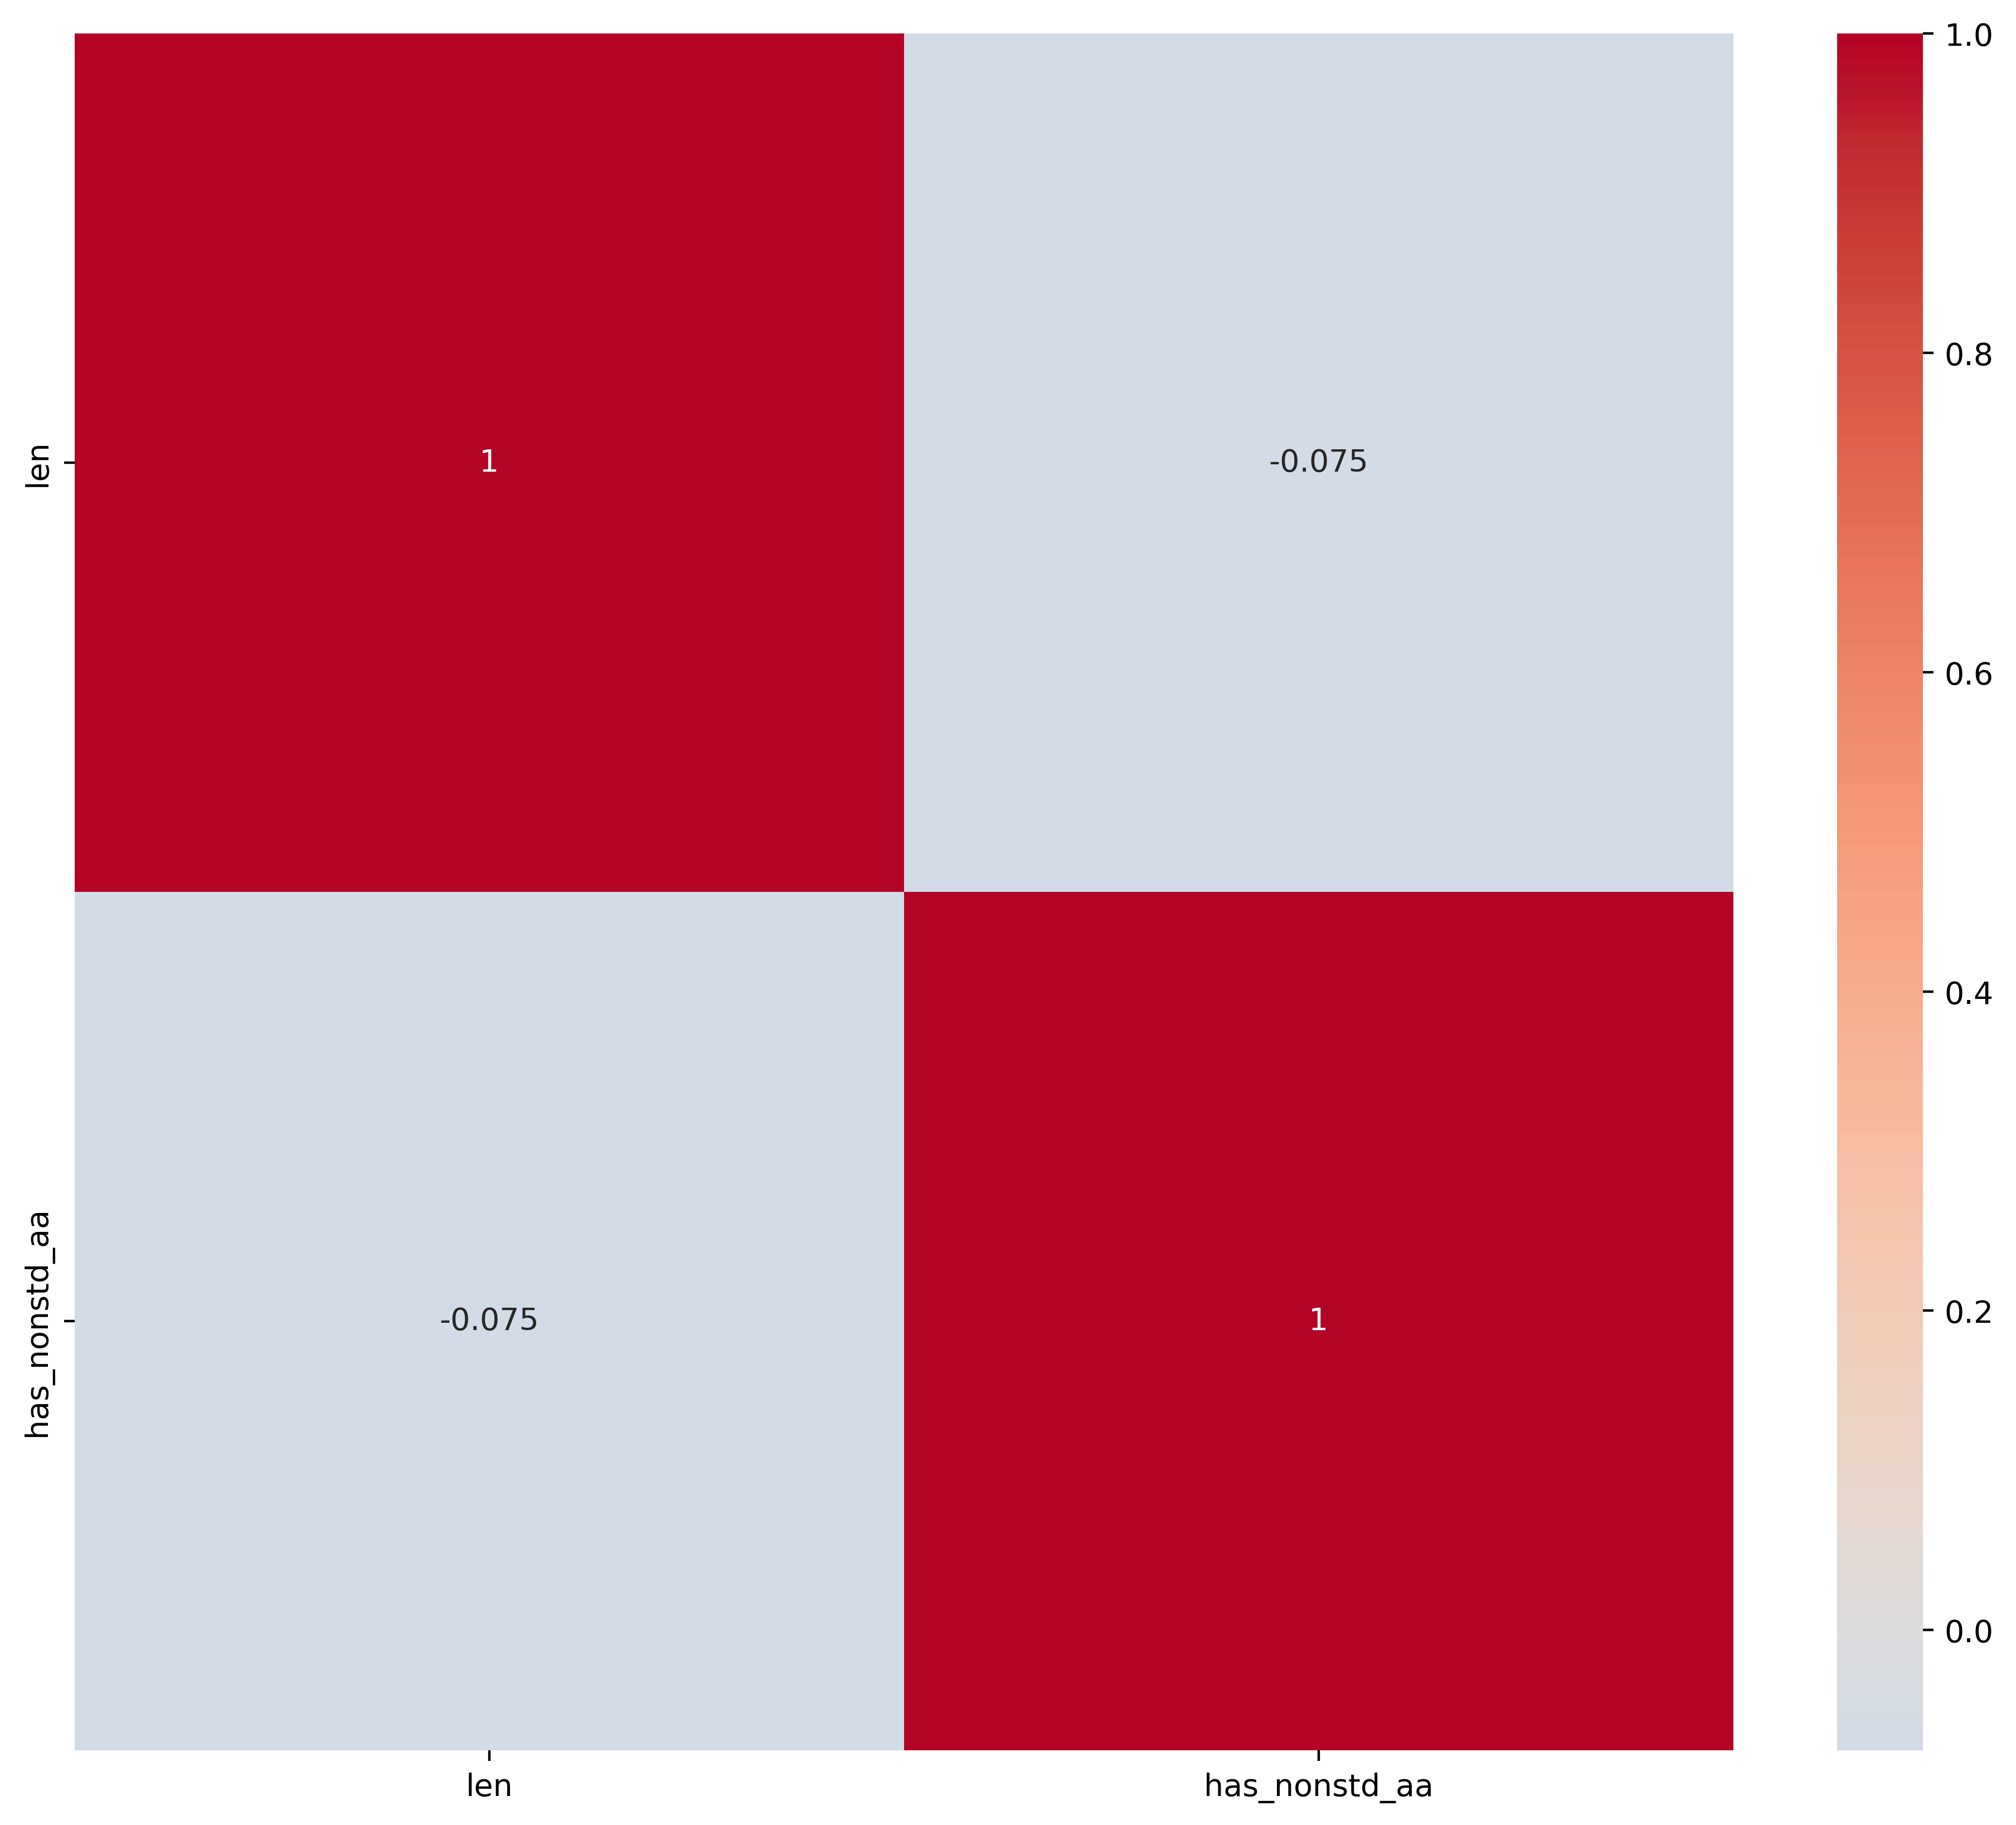

In [6]:
fig, ax = plt.subplots(figsize=(12, 10), dpi=400)

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", center=0, ax=ax);

In [7]:
#the length where 50% of sequences are shorter
np.percentile(df.len, 50)

np.float64(223.0)

Most common length: 231
plot distribution of protein length


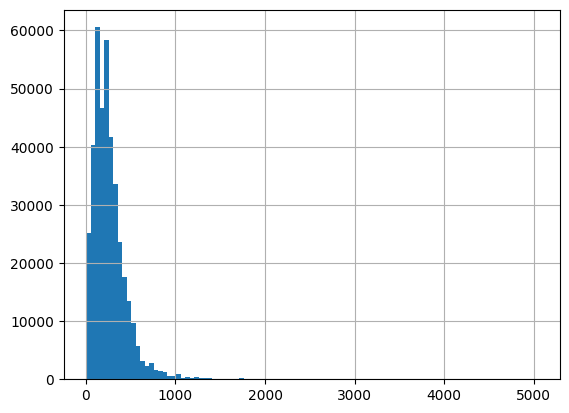

In [8]:
#plot distribution of protein length
df.len.hist(bins=100)
most_common_length = df.len.value_counts().idxmax()
print("Most common length:", most_common_length)
print('plot distribution of protein length')


In [9]:
#selection of specific data
maxlen_seq = 128
input_seqs = df['seq'][(df.len <= maxlen_seq) & (~df.has_nonstd_aa)].values
target_seqs = df['sst3'][(df.len <= maxlen_seq) & (~df.has_nonstd_aa)].values
#Convert sequences into n-grams
def seq2ngrams(seqs, n=3):
    return [[seq[i:i+n] for i in range(len(seq))] for seq in seqs]

input_grams = seq2ngrams(input_seqs)
display(input_grams[0])


['EDL', 'DL', 'L']

In [10]:
#tokenization (convert text → numbers)
tokenizer_encoder = Tokenizer()
tokenizer_encoder.fit_on_texts(input_grams)
input_data = tokenizer_encoder.texts_to_sequences(input_grams)
#padding
input_data = sequence.pad_sequences(input_data, maxlen=maxlen_seq, padding='post')
print(input_data[:10])

[[ 568 7009   24 ...    0    0    0]
 [3358 7562    2 ...    0    0    0]
 [  36 2671    2 ...    0    0    0]
 ...
 [ 883 4668    2 ...    0    0    0]
 [  36 2671    2 ...    0    0    0]
 [ 446 4618    2 ...    0    0    0]]


In [11]:
#Target encoding
tokenizer_decoder = Tokenizer(char_level=True)
tokenizer_decoder.fit_on_texts(target_seqs)
target_data = tokenizer_decoder.texts_to_sequences(target_seqs)
target_data = sequence.pad_sequences(target_data, maxlen=maxlen_seq, padding='post')
target_data = to_categorical(target_data)
target_data[:3]

array([[[0., 1., 0., 0.],
        [0., 0., 0., 1.],
        [0., 1., 0., 0.],
        ...,
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.]],

       [[0., 1., 0., 0.],
        [0., 0., 0., 1.],
        [0., 1., 0., 0.],
        ...,
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.]],

       [[0., 1., 0., 0.],
        [0., 0., 0., 1.],
        [0., 1., 0., 0.],
        ...,
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.]]], shape=(3, 128, 4))

In [12]:
n_words = len(tokenizer_encoder.word_index) + 1
n_tags = len(tokenizer_decoder.word_index) + 1
print(n_words, n_tags)

8421 4


In [13]:
#data structure
input_data.shape, target_data.shape

((88751, 128), (88751, 128, 4))

In [14]:
#Build the model
input = Input(shape=(maxlen_seq,))

In [15]:
#Embedding layer
x = Embedding(input_dim=n_words, output_dim=128)(input)

In [16]:
#Bidirectional LSTM
x = Bidirectional(LSTM(units=64, return_sequences=True, recurrent_dropout=0.1))(x)

In [17]:
#Output layer
y = TimeDistributed(Dense(n_tags, activation="softmax"))(x)
model = Model(input, y)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 128, 128)       │     1,077,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 128, 4)         │           516 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,177,220 (4.49 MB)

 Trainable params: 1,177,220 (4.49 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
#exclude padding 0 from accuracy
def q3_acc(y_true, y_pred):
    y = tf.argmax(y_true, axis=-1)
    y_ = tf.argmax(y_pred, axis=-1)
    mask = tf.greater(y, 0)
    return K.cast(K.equal(tf.boolean_mask(y, mask), tf.boolean_mask(y_, mask)), K.floatx())


In [19]:
#training of medel
model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy", q3_acc])

X_train, X_test, y_train, y_test = train_test_split(input_data, target_data, test_size=.4, random_state=0)
seq_train, seq_test, target_train, target_test = train_test_split(input_seqs, target_seqs, test_size=.4, random_state=0)

model.fit(X_train, y_train, batch_size=128, epochs=5, validation_data=(X_test, y_test), verbose=1)


Epoch 1/5
417/417 ━━━━━━━━━━━━━━━━━━━━ 382s 873ms/step - accuracy: 0.7036 - loss: 0.6029 - q3_acc: 0.5290 - val_accuracy: 0.8070 - val_loss: 0.4536 - val_q3_acc: 0.6940
Epoch 2/5
417/417 ━━━━━━━━━━━━━━━━━━━━ 406s 974ms/step - accuracy: 0.8426 - loss: 0.3785 - q3_acc: 0.7491 - val_accuracy: 0.8566 - val_loss: 0.3513 - val_q3_acc: 0.7727
Epoch 3/5
417/417 ━━━━━━━━━━━━━━━━━━━━ 399s 957ms/step - accuracy: 0.8695 - loss: 0.3248 - q3_acc: 0.7919 - val_accuracy: 0.8725 - val_loss: 0.3170 - val_q3_acc: 0.7979
Epoch 4/5
417/417 ━━━━━━━━━━━━━━━━━━━━ 402s 965ms/step - accuracy: 0.8809 - loss: 0.2999 - q3_acc: 0.8101 - val_accuracy: 0.8737 - val_loss: 0.3177 - val_q3_acc: 0.7999
Epoch 5/5
417/417 ━━━━━━━━━━━━━━━━━━━━ 434s 945ms/step - accuracy: 0.8890 - loss: 0.2813 - q3_acc: 0.8231 - val_accuracy: 0.8872 - val_loss: 0.2855 - val_q3_acc: 0.8212


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
training
---
Input: MGDKPIWEQIGSSFINHYYQLFDNDRTQLGAIYIDASCLTWEGQQFQGKAAIVEKLSSLPFQKIQHSITAQDHQPTPDSCIISMVVGQLKADEDPIMGFHQEFLLKNINDAWVCTNDMFRLALHNFG
Target: CCCCCHHHHHHHHHHHHHHHHHHHCHHHHHHHCCCCCEEEECCEEEECHHHHHHHHHHCCCCCEEEEEEEEEEEECCCCCEEEEEEEEEEECCCCCEEEEEEEEEEECCCCEEEEEEEEEEECCCCC
Result: CCCCHHHHHHHHHHHHHHHHHHHHHHHHHHHEEEEEEEEEECCEEEECHHHHHHHHHHCCCCCEEEEEEEEEEEECCCCCEEEEEEEEEEECCCCEEEEEEEEEEEECCCEEEEEEEEEEECCCCCC


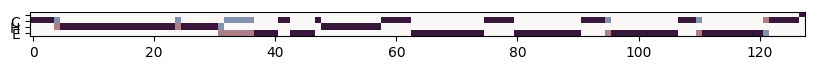

---
Input: SRGTQTE
Target: CEEEECC
Result: CCCCCCC


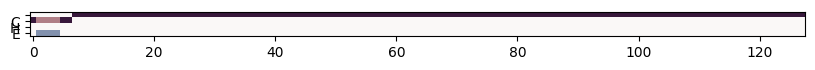

---
Input: MKEEKRSSTGFLVKQRAFLKLYMITMTEQERLYGLKLLKVLQSEFKEIGFKPNHTEVYRSLHELLDDGILKQIKVKKEGAKLQEVVLYQFKDYEAAKLYKKQLKVELDRCKKLIEKALSDNF
Target: CCCCCCCCCCCCCCHHHHHHHHHHHHHHCCCEECCCCHHHHHHHHCCCCCCCCHHHHHHHHHHHHHCCCEEEEECCCCCCCCCCCEEEEECCHHHHHHHHHHHHHHHHHHHHHHHHHHHHHC
Result: CCCCCCCCCCCCCCHHHHHHHHHHHHHHHCCCHHHHHHHHHHHHHCCCCCCCCHHHHHHHHHHHHHCCCEEEEEEECCCCCCCEEEEEEECCHHHHHHHHHHHHHHHHHHHHHHHHHHHHHC


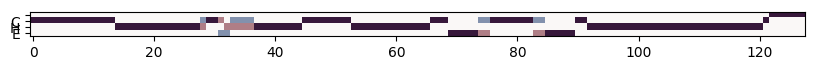

testing
---
Input: MKRQKRDRLERAHQRGYQAGIAGRSKEMCPYQTLNQRSQWLGGWREAMADRVVMAHHHHHH
Target: CCCCCHHHHHHHHHHHHHHHHCCCCCCCCCCCCHHHHHHHHHHHHHHHHHCCCCCCCCCCC
Result: CCCCHHHHHHHHHHHHHHHHHHHCCCCCCCCCECHHHHHHHHHHHHHHHHHCCCCCCCCCC


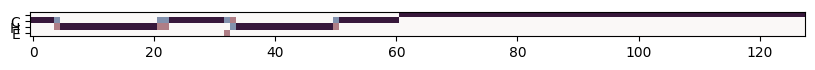

---
Input: YCQKWMWTCDEERKCCEGLVCRLWCKRIINM
Target: CCCCCCCECCCCCCCCCCCECCCECECCCCC
Result: CCCCCEEEEEECEEEEEEEECCCCCCCCCCC


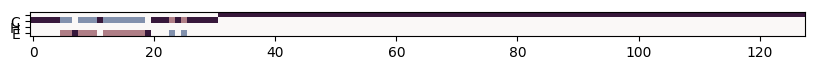

---
Input: TEFSEEQKRTLDLLFLFDRRMTEERRRWLSQRLGLNEEQIERWFRRKEQQI
Target: CCCCCCHHHHHHHHHHHHHHHHHHHHHHHHHHCCCCHHHHHHHHHCCCCCC
Result: CCCCHHHHHHHHHHHHHHHHHHHHHHHHHHHHHCCCHHHHHHHHHHHHCCC


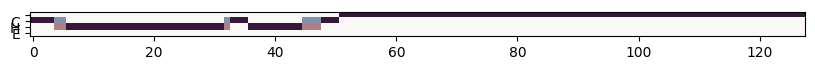

In [33]:
def onehot_to_seq(oh_seq, index):
    s = ''
    for o in oh_seq:
        i = np.argmax(o)
        if i != 0:
            s += index[i]
        else:
            break
    return s

def plot_results(x, y, y_):
    y_ = np.eye(y_.shape[-1])[np.argmax(y_, axis=-1)]
    print("---")
    print("Input: " + str(x))
    print("Target: " + str(onehot_to_seq(y, revsere_decoder_index).upper()))
    print("Result: " + str(onehot_to_seq(y_, revsere_decoder_index).upper()))
    fig = plt.figure(figsize=(10,2))
    plt.imshow(y.T, cmap='Blues')
    plt.imshow(y_.T, cmap='Reds', alpha=.5)
    plt.yticks(range(4), [' '] + [revsere_decoder_index[i+1].upper() for i in range(3)])
    plt.show()
    
revsere_decoder_index = {value:key for key,value in tokenizer_decoder.word_index.items()}
revsere_encoder_index = {value:key for key,value in tokenizer_encoder.word_index.items()}

N=3
y_train_pred = model.predict(X_train[:N])
y_test_pred = model.predict(X_test[:N])
print('training')
for i in range(N):
    plot_results(seq_train[i], y_train[i], y_train_pred[i])
print('testing')
for i in range(N):
    plot_results(seq_test[i], y_test[i], y_test_pred[i])


Running for n=1
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
training
---
Input: MGDKPIWEQIGSSFINHYYQLFDNDRTQLGAIYIDASCLTWEGQQFQGKAAIVEKLSSLPFQKIQHSITAQDHQPTPDSCIISMVVGQLKADEDPIMGFHQEFLLKNINDAWVCTNDMFRLALHNFG
Target: CCCCCHHHHHHHHHHHHHHHHHHHCHHHHHHHCCCCCEEEECCEEEECHHHHHHHHHHCCCCCEEEEEEEEEEEECCCCCEEEEEEEEEEECCCCCEEEEEEEEEEECCCCEEEEEEEEEEECCCCC
Result: CCCCCEEEECCCCEEEEEEEEECCCCCEEEEEEEECCEEEHHCHHHHCHHHHHHHHCCCHHHHHEEEEECCCCCCCCCCEEEEEEECCCCCCCCCCCCHHHHEEEECCCCEEEECCHHHHHHHHCCC


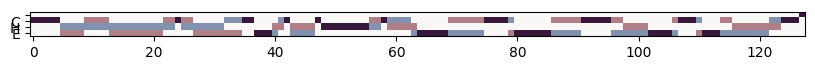

---
Input: SRGTQTE
Target: CEEEECC
Result: CCCCCCC


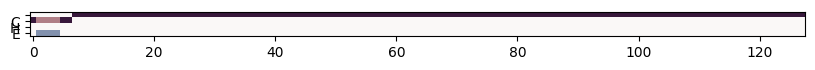

---
Input: MKEEKRSSTGFLVKQRAFLKLYMITMTEQERLYGLKLLKVLQSEFKEIGFKPNHTEVYRSLHELLDDGILKQIKVKKEGAKLQEVVLYQFKDYEAAKLYKKQLKVELDRCKKLIEKALSDNF
Target: CCCCCCCCCCCCCCHHHHHHHHHHHHHHCCCEECCCCHHHHHHHHCCCCCCCCHHHHHHHHHHHHHCCCEEEEECCCCCCCCCCCEEEEECCHHHHHHHHHHHHHHHHHHHHHHHHHHHHHC
Result: CCCCCCCCCCHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHCCCCCCCCHHHHHHHHHHHCCHHHHHHHHHHCCHHHHHHHHHCCCHHHHHHHHHHHHHHHHHHHHHHHHHHCCCC


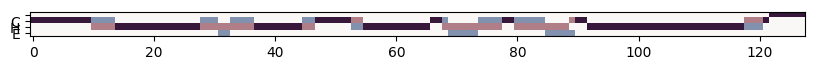

testing
---
Input: MKRQKRDRLERAHQRGYQAGIAGRSKEMCPYQTLNQRSQWLGGWREAMADRVVMAHHHHHH
Target: CCCCCHHHHHHHHHHHHHHHHCCCCCCCCCCCCHHHHHHHHHHHHHHHHHCCCCCCCCCCC
Result: CCCCCCCHHHHHHHHCCCCCCCCCCCCCCCHHCHHHHHHHCCCHHHHHHCHHHCCCCCCCC


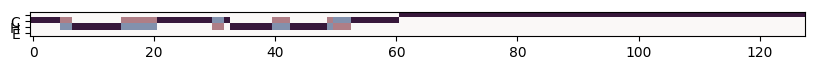

---
Input: YCQKWMWTCDEERKCCEGLVCRLWCKRIINM
Target: CCCCCCCECCCCCCCCCCCECCCECECCCCC
Result: CCCCCCCCCCHHHHHHHHHHHHHHHHHCCCC


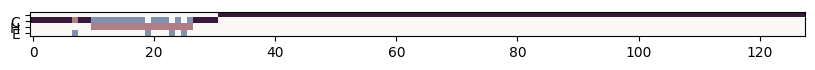

---
Input: TEFSEEQKRTLDLLFLFDRRMTEERRRWLSQRLGLNEEQIERWFRRKEQQI
Target: CCCCCCHHHHHHHHHHHHHHHHHHHHHHHHHHCCCCHHHHHHHHHCCCCCC
Result: CCCCHHHHHHHHHHHHHHHHHHHHHHHHHHHHHCCHHHHHHHHHHHHHCCC


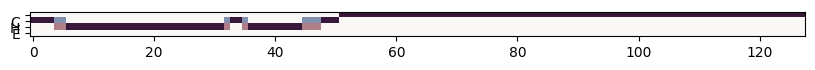


Running for n=3
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
training
---
Input: MGDKPIWEQIGSSFINHYYQLFDNDRTQLGAIYIDASCLTWEGQQFQGKAAIVEKLSSLPFQKIQHSITAQDHQPTPDSCIISMVVGQLKADEDPIMGFHQEFLLKNINDAWVCTNDMFRLALHNFG
Target: CCCCCHHHHHHHHHHHHHHHHHHHCHHHHHHHCCCCCEEEECCEEEECHHHHHHHHHHCCCCCEEEEEEEEEEEECCCCCEEEEEEEEEEECCCCCEEEEEEEEEEECCCCEEEEEEEEEEECCCCC
Result: CCCCCEEHHHHHHHHHHHHHHHHHHHHHHHHEEEEEEEEEEEEEEEEHHHHHHHHHHHHHHHHHEEEEEEEEEEECCCCEEEEEEEEEEEECCCCCHEEEEEEEEHCCCCEEEEEEEEEEEEECCCC


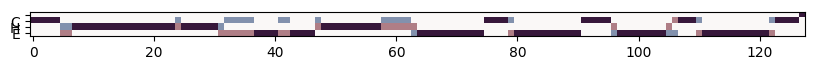

---
Input: SRGTQTE
Target: CEEEECC
Result: CCCCCCC


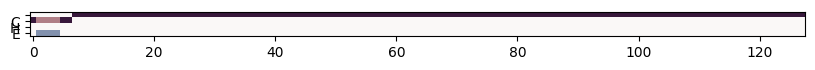

---
Input: MKEEKRSSTGFLVKQRAFLKLYMITMTEQERLYGLKLLKVLQSEFKEIGFKPNHTEVYRSLHELLDDGILKQIKVKKEGAKLQEVVLYQFKDYEAAKLYKKQLKVELDRCKKLIEKALSDNF
Target: CCCCCCCCCCCCCCHHHHHHHHHHHHHHCCCEECCCCHHHHHHHHCCCCCCCCHHHHHHHHHHHHHCCCEEEEECCCCCCCCCCCEEEEECCHHHHHHHHHHHHHHHHHHHHHHHHHHHHHC
Result: CCCCCCCCCCCEHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHCCCCHHHHHHHHHHHHHHHHHHHEEEEECCCCCCCCEEEEEECHHHHHHHHHHHHHHHHHHHHHHHHHHHHHCCC


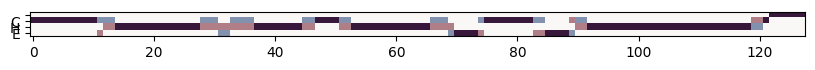

testing
---
Input: MKRQKRDRLERAHQRGYQAGIAGRSKEMCPYQTLNQRSQWLGGWREAMADRVVMAHHHHHH
Target: CCCCCHHHHHHHHHHHHHHHHCCCCCCCCCCCCHHHHHHHHHHHHHHHHHCCCCCCCCCCC
Result: CCCCHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHCCCCCCCC


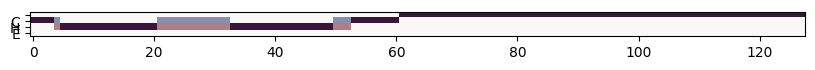

---
Input: YCQKWMWTCDEERKCCEGLVCRLWCKRIINM
Target: CCCCCCCECCCCCCCCCCCECCCECECCCCC
Result: CCCCCCCCCCCCCEEECCCECEECCCEEECC


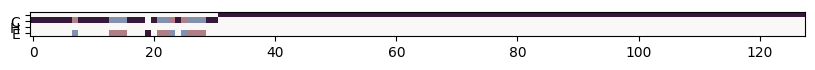

---
Input: TEFSEEQKRTLDLLFLFDRRMTEERRRWLSQRLGLNEEQIERWFRRKEQQI
Target: CCCCCCHHHHHHHHHHHHHHHHHHHHHHHHHHCCCCHHHHHHHHHCCCCCC
Result: CCCCHHHHHHHHHHHHHHHHHHHHHHHHHHHHHCHHHHHHHHHHHHHHHCC


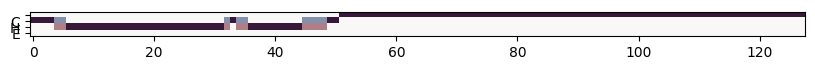


Running for n=5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
training
---
Input: MGDKPIWEQIGSSFINHYYQLFDNDRTQLGAIYIDASCLTWEGQQFQGKAAIVEKLSSLPFQKIQHSITAQDHQPTPDSCIISMVVGQLKADEDPIMGFHQEFLLKNINDAWVCTNDMFRLALHNFG
Target: CCCCCHHHHHHHHHHHHHHHHHHHCHHHHHHHCCCCCEEEECCEEEECHHHHHHHHHHCCCCCEEEEEEEEEEEECCCCCEEEEEEEEEEECCCCCEEEEEEEEEEECCCCEEEEEEEEEEECCCCC
Result: CCCCHHHHHHHHHHHHHHHHHHHHHHHHHHHEEEEEEEEEECCEEEECHHHHHHHHHHCCCCCEEEEEEEEEEEECCCCCEEEEEEEEEEECCCCEEEEEEEEEEEECCCEEEEEEEEEEECCCCCC


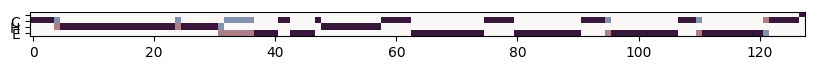

---
Input: SRGTQTE
Target: CEEEECC
Result: CCCCCCC


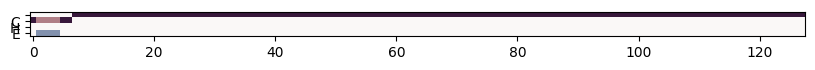

---
Input: MKEEKRSSTGFLVKQRAFLKLYMITMTEQERLYGLKLLKVLQSEFKEIGFKPNHTEVYRSLHELLDDGILKQIKVKKEGAKLQEVVLYQFKDYEAAKLYKKQLKVELDRCKKLIEKALSDNF
Target: CCCCCCCCCCCCCCHHHHHHHHHHHHHHCCCEECCCCHHHHHHHHCCCCCCCCHHHHHHHHHHHHHCCCEEEEECCCCCCCCCCCEEEEECCHHHHHHHHHHHHHHHHHHHHHHHHHHHHHC
Result: CCCCCCCCCCCCCCHHHHHHHHHHHHHHHCCCHHHHHHHHHHHHHCCCCCCCCHHHHHHHHHHHHHCCCEEEEEEECCCCCCCEEEEEEECCHHHHHHHHHHHHHHHHHHHHHHHHHHHHHC


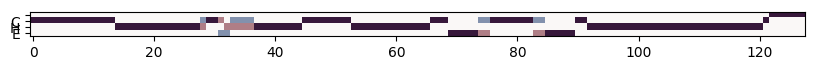

testing
---
Input: MKRQKRDRLERAHQRGYQAGIAGRSKEMCPYQTLNQRSQWLGGWREAMADRVVMAHHHHHH
Target: CCCCCHHHHHHHHHHHHHHHHCCCCCCCCCCCCHHHHHHHHHHHHHHHHHCCCCCCCCCCC
Result: CCCCHHHHHHHHHHHHHHHHHHHCCCCCCCCCECHHHHHHHHHHHHHHHHHCCCCCCCCCC


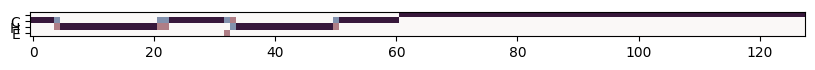

---
Input: YCQKWMWTCDEERKCCEGLVCRLWCKRIINM
Target: CCCCCCCECCCCCCCCCCCECCCECECCCCC
Result: CCCCCEEEEEECEEEEEEEECCCCCCCCCCC


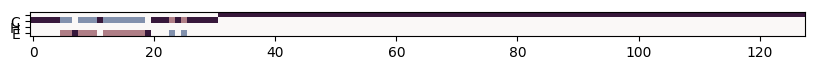

---
Input: TEFSEEQKRTLDLLFLFDRRMTEERRRWLSQRLGLNEEQIERWFRRKEQQI
Target: CCCCCCHHHHHHHHHHHHHHHHHHHHHHHHHHCCCCHHHHHHHHHCCCCCC
Result: CCCCHHHHHHHHHHHHHHHHHHHHHHHHHHHHHCCCHHHHHHHHHHHHCCC


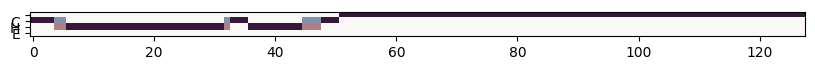

In [21]:
results = {}

for n in [1, 3, 5]:
    print(f"\nRunning for n={n}")
    
    # 1. Create n-grams
    input_grams = seq2ngrams(input_seqs, n)
    input_grams = [' '.join(seq) for seq in input_grams]
    
    # 2. Tokenizer
    tokenizer_encoder = Tokenizer()
    tokenizer_encoder.fit_on_texts(input_grams)
    input_data = tokenizer_encoder.texts_to_sequences(input_grams)
    input_data = sequence.pad_sequences(input_data, maxlen=maxlen_seq, padding='post')
    
    # 3. Targets (same as before)
    tokenizer_decoder = Tokenizer(char_level=True)
    tokenizer_decoder.fit_on_texts(target_seqs)
    target_data = tokenizer_decoder.texts_to_sequences(target_seqs)
    target_data = sequence.pad_sequences(target_data, maxlen=maxlen_seq, padding='post')
    target_data = to_categorical(target_data)
    
    # 4. Split
    X_train, X_test, y_train, y_test = train_test_split(
        input_data, target_data, test_size=0.4, random_state=0
    )
    
    # 5. Build model
    n_words = len(tokenizer_encoder.word_index) + 1
    n_tags = len(tokenizer_decoder.word_index) + 1
    
    input_layer = Input(shape=(maxlen_seq,))
    x = Embedding(input_dim=n_words, output_dim=128)(input_layer)
    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    output = TimeDistributed(Dense(n_tags, activation="softmax"))(x)
    
    model = Model(input_layer, output)
    model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"])
    
    # 6. Train
    model.fit(X_train, y_train, batch_size=128, epochs=3, verbose=0)
    
    # 7. Evaluate
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    results[n] = acc

    N=3
    y_train_pred = model.predict(X_train[:N])
    y_test_pred = model.predict(X_test[:N])
    print('training')
    for i in range(N):
        plot_results(seq_train[i], y_train[i], y_train_pred[i])
    print('testing')
    for i in range(N):
        plot_results(seq_test[i], y_test[i], y_test_pred[i])

In [22]:
display(results)

{1: 0.816485583782196, 3: 0.869911253452301, 5: 0.8993104696273804}